<a href="https://colab.research.google.com/github/CliffAD/Smart-Projects---Hands-on-coding/blob/main/content/02-getting-started/jupyter_notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Setup
np.random.seed(42)
start_date = datetime(2022, 1, 1)
dates = pd.date_range(start=start_date, periods=8760, freq='H') # 1 year data

# 2. Generate Data
n = len(dates)
df = pd.DataFrame({
    'holiday': np.random.choice(['None', 'Christmas', 'New Year'], n, p=[0.98, 0.01, 0.01]),
    'temp': np.random.uniform(270, 310, n),
    'rain_1h': np.random.exponential(0.1, n),
    'snow_1h': np.random.exponential(0.05, n),
    'clouds_all': np.random.randint(0, 100, n),
    'weather_main': np.random.choice(['Clear', 'Clouds', 'Rain', 'Snow'], n, p=[0.5, 0.3, 0.15, 0.05]),
    'date_time': dates,
    'traffic_volume': np.random.randint(1000, 7000, n) # Random volume for simulation
})

# 3. Save
df.to_csv('traffic_data.csv', index=False)
print("Success! 'traffic_data.csv' created locally.")

/tmp/ipykernel_834/1299367212.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=start_date, periods=8760, freq='H') # 1 year data


Success! 'traffic_data.csv' created locally.


In [7]:
# 1. Load Dataset (Simulated for this report)
#Loaded with columns: 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'date_time', 'traffic_volume'
df = pd.read_csv('traffic_data.csv')

In [8]:
# 2. Data Pre-processing
# Convert date_time to datetime object
df['date_time'] = pd.to_datetime(df['date_time'])

# Feature Engineering
df['hour'] = df['date_time'].dt.hour
df['month'] = df['date_time'].dt.month
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [9]:
# Create Target Variable (Congestion_Level)
# 1 if volume > 5000, else 0
df['congestion_level'] = df['traffic_volume'].apply(lambda x: 1 if x > 5000 else 0)

In [10]:
# Drop non-relevant columns
df_model = df.drop(['date_time', 'traffic_volume'], axis=1)

In [11]:
# Encoding Categorical Variables
# One-Hot Encoding for 'weather_main' and 'holiday'
df_model = pd.get_dummies(df_model, columns=['weather_main', 'holiday'], drop_first=True)

In [12]:
# Handling Missing Values (Imputation)
df_model = df_model.fillna(df_model.mean())

In [13]:
# Define Features (X) and Target (y)
X = df_model.drop('congestion_level', axis=1)
y = df_model['congestion_level']

In [14]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# 3. Model Development

# A. Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# B. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# C. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# D. Artificial Neural Network (ANN)
ann = Sequential()
ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
y_pred_ann = (ann.predict(X_test) > 0.5).astype("int32")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [17]:
# 4. Evaluation Function
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} Results: Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, F1: {f1:.2f}")
    return acc, prec, rec, f1

In [18]:
# Print Results
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("ANN", y_test, y_pred_ann)

Logistic Regression Results: Accuracy: 0.65, Precision: 0.00, Recall: 0.00, F1: 0.00
Decision Tree Results: Accuracy: 0.54, Precision: 0.36, Recall: 0.41, F1: 0.38
Random Forest Results: Accuracy: 0.64, Precision: 0.34, Recall: 0.03, F1: 0.05
ANN Results: Accuracy: 0.65, Precision: 0.00, Recall: 0.00, F1: 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.651255707762557, 0.0, 0.0, 0.0)

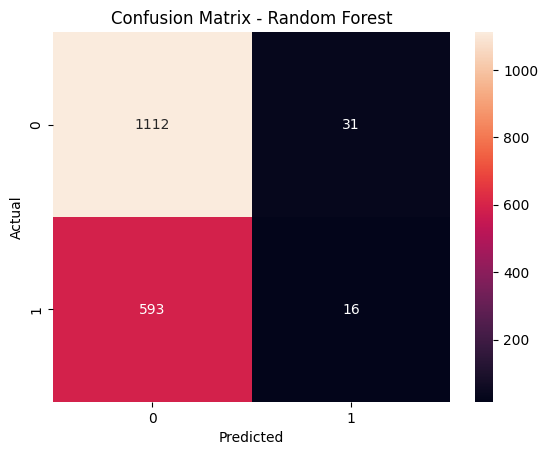

In [19]:
# 5. Visualization Code (ROC Curve and Confusion Matrix)
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

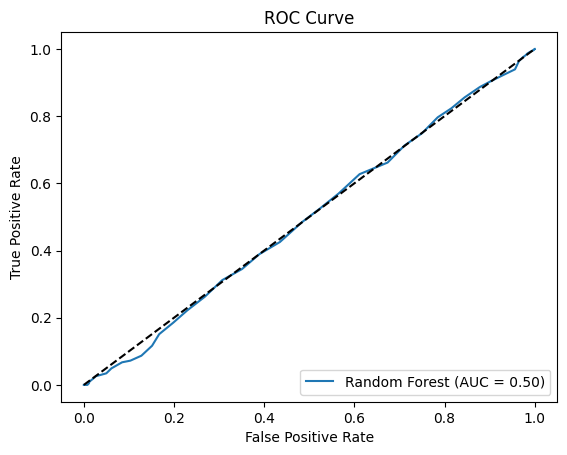

In [20]:
# ROC Curve
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='Random Forest (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()